In [3]:
import sys
sys.path.append('../../src/')
import TFIM_operators_from_states as op
from project_imports import *

In [4]:
import numpy as np

def uv_tfim(g, k):
    """
    Ground-state Bogoliubov coefficients (u_k, v_k)
    for 1D TFIM at field g.
    
    k : array (0 < k < pi)
    g : scalar or array broadcastable with k
    """
    eps = np.sqrt((g - np.cos(k))**2 + np.sin(k)**2)

    u = np.sqrt(0.5 * (1 + (g - np.cos(k)) / eps))
    v = np.sqrt(0.5 * (1 - (g - np.cos(k)) / eps))

    return u, v

def ab_tfim_u(alpha,beta,g,k):
    u_g,v_g = uv_tfim(g,k)
    u = alpha * u_g - 1j * beta * v_g
    #v = -1j * alpha * v_g + beta * u_g
    return u
def ab_tfim_v(alpha,beta,g,k):
    u_g,v_g = uv_tfim(g,k)
    #u = alpha * u_g - 1j * beta * v_g
    v = -1j * alpha * v_g + beta * u_g
    return v

def u0(alpha,beta,g,k):
    return array([ab_tfim_u(alpha,beta,g,ki) for ki in k])
def v0(alpha,beta,g,k):
    return array([ab_tfim_v(alpha,beta,g,ki) for ki in k])



$\ket{\psi}= \alpha_k \ket{0_g} + \beta_k \ket{1_g}$

The functions ab_tfim_u give us the bogoliouv amplitude needed to express this state in the $\ket{0_c}, \ket{1_c}$ basis.

In [5]:
L = 100 #System Size
k = array([pi/L*(1+2*i) for i in range(0,L//2)]) #Momenta Sectors

g=-0 #g that the state is in reference towards

#Storing weights as a tuple (alpha,beta)

weights = [(1,0),(0,1),(sqrt(1/2),sqrt(1/2))]
#alpha is the ground state amplitude, beta is the excited state
#Here, we pick the ground state
alpha,beta= weights[0]
u = u0(alpha,beta,g,k)
v = v0(alpha,beta,g,k)
#Must be in the state form [u,v,k] for op. module to work
state0= [u,v,k]
#For instance, we can set these up in the excited state
alpha,beta= weights[1]
u = u0(alpha,beta,g,k)
v = v0(alpha,beta,g,k)
state1= [u,v,k]
#Or, as as uperposition
alpha,beta= weights[-1]
u = u0(alpha,beta,g,k)
v = v0(alpha,beta,g,k)
state2= [u,v,k]


#Example
print("Ground State")
print(r"<X0X1>=", op.sx_correlation([0,1],state0))
print(r"<Z>=", op.sz_correlation([0],state0))
#Example
print("Excited State")
print(r"<X0X1>=", op.sx_correlation([0,1],state1))
print(r"<Z>=", op.sz_correlation([0],state1))
print("Super Position")
print(r"<X0X1>=", op.sx_correlation([0,1],state2))
print(r"<Z>=", op.sz_correlation([0],state2))


Ground State
<X0X1>= (1+0j)
<Z>= 0.0
Excited State
<X0X1>= (-1+0j)
<Z>= 0.0
Super Position
<X0X1>= 0.0
<Z>= 0.0


In [10]:
#Single Mode exictations

In [11]:
L = 100
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
g=0.
tau=10
u = u0(1,0,g,k)
v = v0(1,0,g,k)
states =[]
for i in range(len(k)):
    px = np.exp(-2*pi*sin(k[i])**2*tau)
    beta= sqrt(px)
    alpha= sqrt(1-px)
    ui, vi = u.copy(), v.copy()
    ui[i] = ab_tfim_u(alpha,beta,g,k[i])
    vi[i] = ab_tfim_u(alpha,beta,g,k[i])
    states.append([ui,vi,k])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


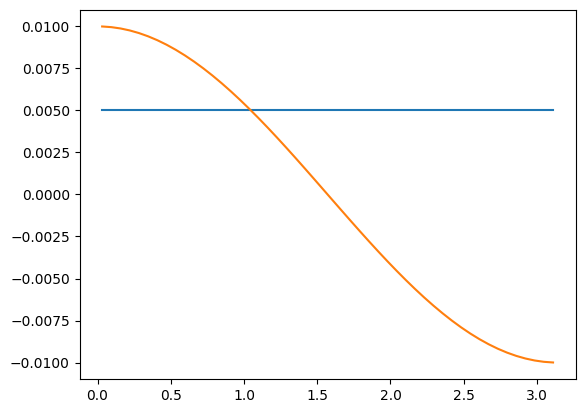

In [12]:
Px = array([op.Px_n(2,s) for s in states])
Pz = array([op.Pz_n(1,s) for s in states])

plot(k,1/2-Px)
plot(k,1/2-Pz)

In [13]:
# landau zener attempt?
L = 100
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
g=0.
taus = np.logspace(-6,2,100)
states=[]
for tau in taus:
    u=[]
    v=[]
    for i in range(len(k)):
        px = np.exp(-2*pi*sin(k[i])**2*tau)
        beta= sqrt(px)
        alpha= sqrt(1-px)
        u.append( ab_tfim_u(alpha,beta,g,k[i]) )
        v.append( ab_tfim_v(alpha,beta,g,k[i]) )

    state= [u,v,k]
    states.append(state)
    #print(op.sz_correlation([0],state))
    #print(op.sx_correlation([0,1],state))

100%|██████████| 100/100 [00:17<00:00,  5.56it/s]


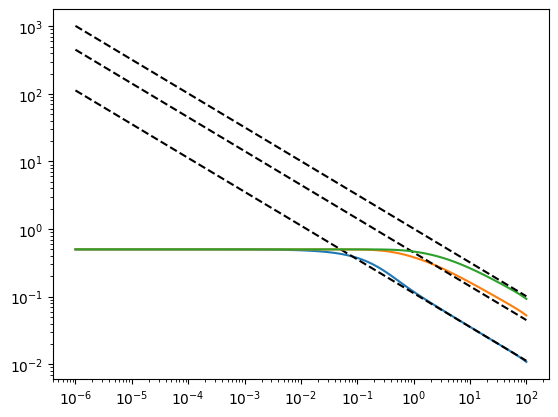

In [15]:
P1 = array([1/2-op.Px_n(2,s) for s in states])

plot(taus,P1)
#loglog()
plot(taus,taus**(-1/2)/sqrt(2)/pi/2*1,"--k")


P2 = array([1/2-op.Px_n(6,s) for s in states])

plot(taus,P2)
loglog()
plot(taus,taus**(-1/2)/sqrt(2)/pi/2*4,"--k")


P3 = array([1/2-op.Px_n(10,s) for s in tqdm(states)])

plot(taus,P3)
loglog()
plot(taus,taus**(-1/2)/sqrt(2)/pi/2*9,"--k")


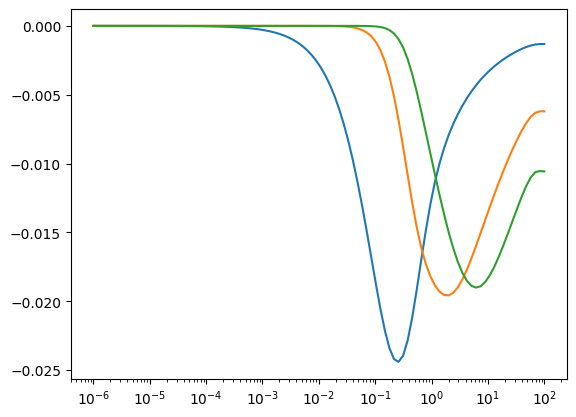

In [16]:
plot(taus/1,(np.gradient(P1)))
plot(taus/1,(np.gradient(P2)))
plot(taus/1,(np.gradient(P3)))

xscale("log")

In [17]:
import numerical_quenches as nq


In [18]:
def g_f(t,args):
    return 0

In [19]:
# landau zener attempt?
L = 100
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
g=0.
taus = np.logspace(-6,2,4)
statesKZ=[]
for tau in taus:
    u=[]
    v=[]
    for i in range(len(k)):
        px = np.exp(-2*pi*sin(k[i])**2*tau)
        beta= sqrt(px)
        alpha= sqrt(1-px)
        u.append( ab_tfim_u(alpha,beta,g,k[i]) )
        v.append( ab_tfim_v(alpha,beta,g,k[i]) )

    state= [u,v,k]
    statesKZ.append(state)
    #print(op.sz_correlation([0],state))
    #print(op.sx_correlation([0,1],state))

g0=0


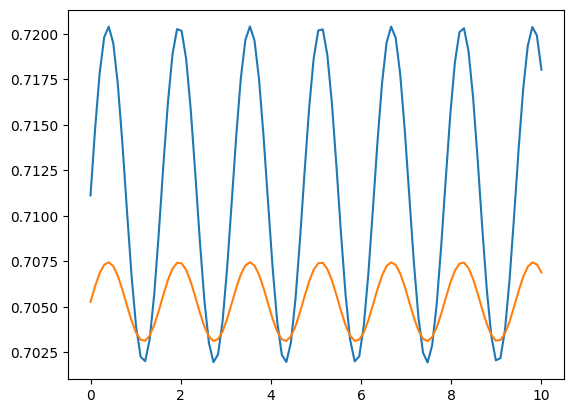

In [20]:
idx = np.argmin(np.abs(k - .5))
gf=0
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])
u = u0.copy()
v = v0.copy()

u[idx] = ab_tfim_u(sqrt(1/2),sqrt(1/2),gf,k[idx])
v[idx] = ab_tfim_v(sqrt(1/2),sqrt(1/2),gf,k[idx])

state0 = [u, v, k]
t_eval = np.linspace(0,10,100)
args= ""
states = nq.states(L,t_eval,g_f,args,state_0 =state0)

x = array([op.Pz_n(1,s) for s in states])
plot(t_eval,-log(x)/1)
x = array([op.Pz_n(4,s) for s in states])
plot(t_eval,-log(x)/4)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
L = 200
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
gf = 0
t_eval = np.linspace(0,2,50)
args = ""
ns = range(1,7)

# precompute ground state once
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

alpha = 0
beta  = 1

def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite only mode j
    u[j] = ab_tfim_u(alpha, beta, gf, k[j])
    v[j] = ab_tfim_v(alpha, beta, gf, k[j])

    state0 = [u, v, k]
    states = nq.states(L, t_eval, g_f, args, state_0=state0)

    results = []
    for n in ns:
        x = np.array([op.Pz_n(n, s) for s in states])
        y = -np.log(x[0])/n
        #results.append(np.max(y) - np.min(y))
        results.append(y)
    return results


# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)        # shape: (len(k), len(ns))


g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0


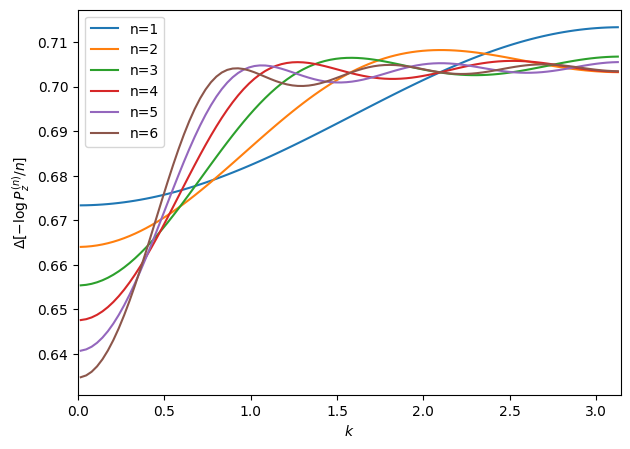

In [22]:

# ---- plot ----
plt.figure(figsize=(7,5))
for i, n in enumerate(ns):
    plt.plot(((pi-k)), (out[:, i]), label=f"n={n}")

plt.xlim(0, np.pi)
plt.xlabel(r"$\frac{1}{nk^*}$")
plt.xlabel(r"$k$")
plt.ylabel(r"$\Delta[-\log P_z^{(n)}/n]$")
plt.legend()
plt.show()

In [ ]:
k= np.linspace(0,pi,300)

g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0
g0=0


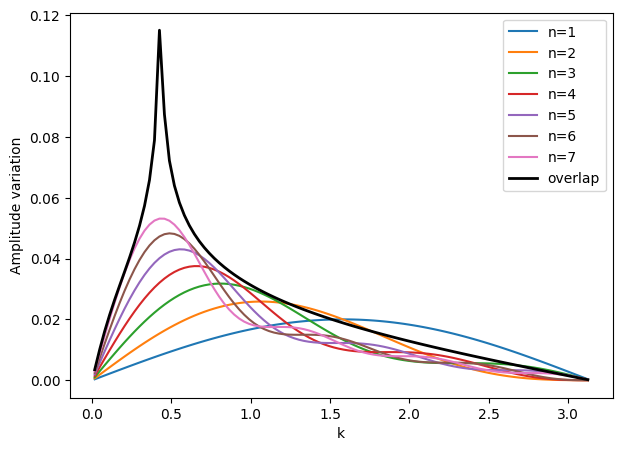

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

gf = 0
t_eval = np.linspace(0,2,200)
args = ""
ns = range(1,8)
L = 2*len(k)
# ground state at final field (for constructing excitations)
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

# ground state for overlap comparison (g = 100 as you wrote)
gs = nq.groundstate(-100, L)

alpha = 1/np.sqrt(2)
beta  = 1/np.sqrt(2)

def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite only mode j
    u[j] = ab_tfim_u(alpha, beta, gf, k[j])
    v[j] = ab_tfim_v(alpha, beta, gf, k[j])

    state0 = [u, v, k]

    states = nq.states(L, t_eval, g_f, args, state_0=state0)

    # ----- Pz_n deltas -----
    results = []
    for n in ns:
        x = np.array([op.Pz_n(n, s) for s in states])
        y = -np.log(x)/n
        results.append(np.max(y) - np.min(y))
    state0= nq.groundstate(1.1,L)
    # ----- overlap delta -----
    ol = np.abs(nq.overlap(states, state0))     # array over time
    y_ol = -np.log((ol)**2) / L
    delta_ol = np.max(y_ol) - np.min(y_ol)

    return results + [delta_ol]


# parallel over modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)   # shape: (len(k), len(ns)+1)

# ---- plot ----
plt.figure(figsize=(7,5))

# Pz_n curves
for i, n in enumerate(ns):
    plt.plot(pi-k, out[:, i], label=f"n={n}")

# overlap curve (black)
plt.plot(pi-k, out[:, -1], 'k', linewidth=2, label="overlap")

plt.xlabel("k")
plt.ylabel(r"Amplitude variation")
plt.legend()
plt.show()

# Sigma  Xprojectors 

In [1]:
def g_f(t,args):
    gf= args
    return gf
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
L = 100
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
gf = 0.1
t_eval = np.linspace(0,2,50)
args = gf
ns =  [2,3,4,5]

# precompute ground state once
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

alpha = 0
beta  = 1

def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite only mode j
    u[j] = ab_tfim_u(alpha, beta, gf, k[j])
    v[j] = ab_tfim_v(alpha, beta, gf, k[j])

    state0 = [u, v, k]
    states = nq.states(L, t_eval, g_f, args, state_0=state0)

    results = []
    for n in ns:
        x = np.array([op.Px_n(n, s) for s in states])
        results.append(-log(x)/n)
    return results


# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)        # shape: (len(k), len(ns))


NameError: name 'array' is not defined

In [181]:
def g_f(t,args):
    gf= args
    return gf
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
L = 500
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
gf = 0
t_eval = np.linspace(0,2,50)
args = gf
ns =  [2,3,4,5,6,7,8,9,10,11]

# precompute ground state once
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

alpha = 0
beta  = 1


def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite all modes with k_index <= j

    for m in range(j+1):
        u[m] = ab_tfim_u(alpha, beta, gf, k[m])
        v[m] = ab_tfim_v(alpha, beta, gf, k[m])

    state0 = [u, v, k]
    
    #states = nq.states(L, t_eval, g_f, args, state_0=state0)

    results = array([ (op.Px_n(n,state0)) for n in ns])
    #results=[]
    
    for n in ns:
        pass
        #x = np.array([op.Px_n(n, s) for s in states])
        #results.append(np.max(x) - np.min(x))

    return results

# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)        # shape: (len(k), len(ns))


In [2]:

# ---- plot ----
plt.figure(figsize=(7,5))
for i, n in enumerate(ns):
    plt.plot(pi-k, (out[:, i]), label=f"n={n}")
plt.xlim(0, np.pi)
plt.xlabel(r"$\frac{1}{nk^*}$")
plt.xlabel(r"$k^*$")
plt.ylabel(r"$\Delta_n(k^*)$")
plt.legend()
plt.title(r"Final State Projectors with defects: $ \Delta_n(k^*) =\int _0^{k^*}dk \langle k,-k | P^x| k,-k \rangle$")
plt.show()
# ---- plot ----
plt.figure(figsize=(7,5))
for i, n in enumerate(ns):
    plt.plot(1/k/k, (1/2-(out[:, i]))/(n-1), label=f"n={n}")
plt.xlabel(r"$\frac{1}{(k^*)^2}\sim \tau$")
plt.title(r"$ \frac{1/2- \Delta_n(k^*)}{n-1} $")

plt.ylabel(r"$\frac{1/2-\Delta_n(k^*)}{n-1}$")
plt.legend()


loglog()
plt.show()

NameError: name 'ns' is not defined

<Figure size 700x500 with 0 Axes>

In [ ]:


tau = (xi/2/pi)**2/2

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


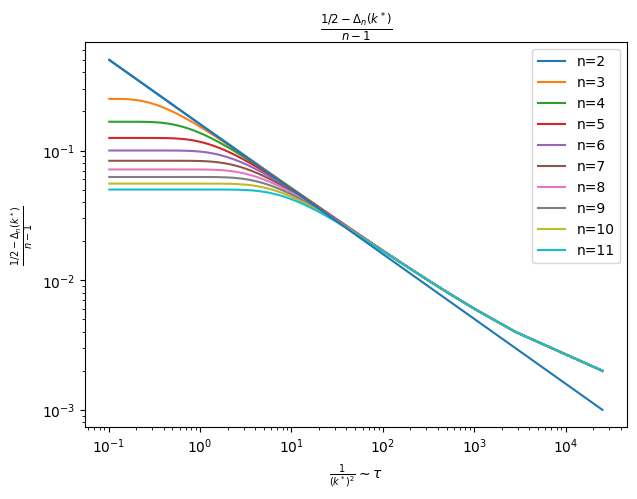

In [192]:
# ---- plot ----
plt.figure(figsize=(7,5))
tau = 1/k/k

for i, n in enumerate(ns):
    plt.plot(tau, ((1/2-(out[:, i]))/(n-1)), label=f"n={n}")

plot(tau,tau**(-1/2)/2/pi)
plt.xlabel(r"$\frac{1}{(k^*)^2}\sim \tau$")
plt.title(r"$ \frac{1/2- \Delta_n(k^*)}{n-1} $")

plt.ylabel(r"$\frac{1/2-\Delta_n(k^*)}{n-1}$")
plt.legend()


loglog()
plt.show()

In [373]:
def g_f(t,args):
    gf= args
    return gf
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
L = 1000
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
gf = 0
t_eval = np.linspace(0,2,50)
args = gf
ns =  [2,3,4,5,6,7,8,9,10,11,12,13]

# precompute ground state once
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

alpha = 0
beta  = 1
taus = np.logspace(-3,4,100)

def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite all modes with k_index <= j

    for m in range(len(k)):
        Pk = (exp(-2*pi*sin(pi-k[m])**2*taus[j]))
        beta= sqrt(Pk)
        alpha = sqrt(1 - Pk)
        u[m] = ab_tfim_u(alpha, beta, gf, k[m])
        v[m] = ab_tfim_v(alpha, beta, gf, k[m])

    state0 = [u, v, k]
    
    #states = nq.states(L, t_eval, g_f, args, state_0=state0)

    results = array([ (op.Px_n(n,state0)) for n in ns])
    #results=[]
    
    for n in ns:
        pass
        #x = np.array([op.Px_n(n, s) for s in states])
        #results.append(np.max(x) - np.min(x))

    return results

# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(taus))
)

out = np.array(out)        # shape: (len(k), len(ns))


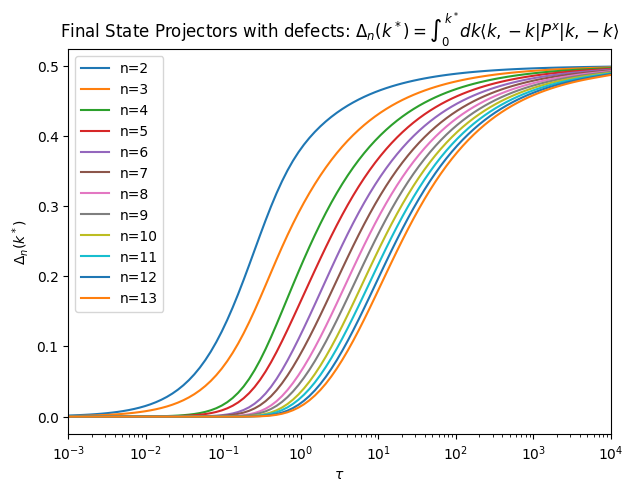

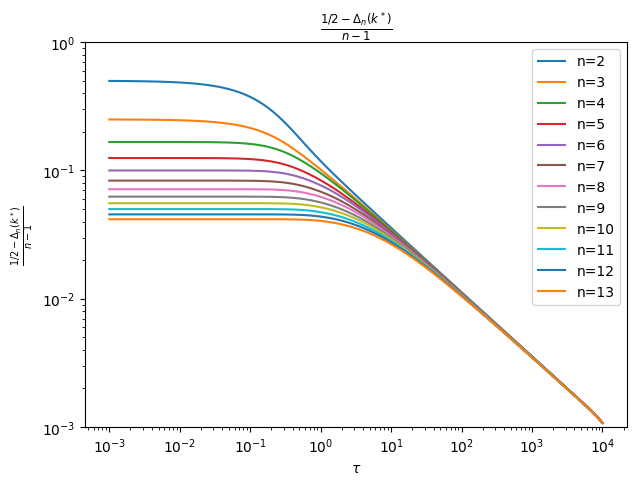

In [374]:

# ---- plot ----
plt.figure(figsize=(7,5))
for i, n in enumerate(ns):
    plt.plot(taus, (out[:, i]), label=f"n={n}")
plt.xlim(0.001, taus[-1])
plt.xlabel(r"$\frac{1}{nk^*}$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\Delta_n(k^*)$")
plt.legend()
plt.title(r"Final State Projectors with defects: $ \Delta_n(k^*) =\int _0^{k^*}dk \langle k,-k | P^x| k,-k \rangle$")
xscale("log")
show()
# ---- plot ----
plt.figure(figsize=(7,5))
for i, n in enumerate(ns):
    plt.plot(taus, (1/2-(out[:, i]))/(n-1), label=f"n={n}")
plt.xlabel(r"$\tau$")
plt.title(r"$ \frac{1/2- \Delta_n(k^*)}{n-1} $")

plt.ylabel(r"$\frac{1/2-\Delta_n(k^*)}{n-1}$")
plt.legend()
ylim(10e-4,1)

loglog()
plt.show()

In [375]:
def compute_for_mode(j):

    tau = taus[j]

    # ---------- Landau-Zener excitation ----------
    u_lz = u0.copy()
    v_lz = v0.copy()

    for m in range(len(k)):
        Pk = exp(-2*pi*sin(k[m])**2 * tau)

        beta  = sqrt(Pk)
        alpha = sqrt(1 - Pk)

        u_lz[m] = ab_tfim_u(alpha, beta, gf, k[m])
        v_lz[m] = ab_tfim_v(alpha, beta, gf, k[m])

    state_lz = [u_lz, v_lz, k]


    # ---------- step excitation (all k < k*) ----------
    u_step = u0.copy()
    v_step = v0.copy()

    kstar = 1/sqrt(2*tau)

    for m in range(len(k)):
        if k[m] <= kstar:
            u_step[m] = ab_tfim_u(0,1,gf,k[m])
            v_step[m] = ab_tfim_v(0,1,gf,k[m])

    state_step = [u_step, v_step, k]


    res_lz   = array([op.Px_n(n, state_lz)   for n in ns])
    res_step = array([op.Px_n(n, state_step) for n in ns])

    return res_lz, res_step

In [376]:
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(taus))
)

out = np.array(out)

In [377]:
out.shape = (len(taus), 2, len(ns))

out_lz= out[:,0,:]  
out_step= out[:,1,:]  

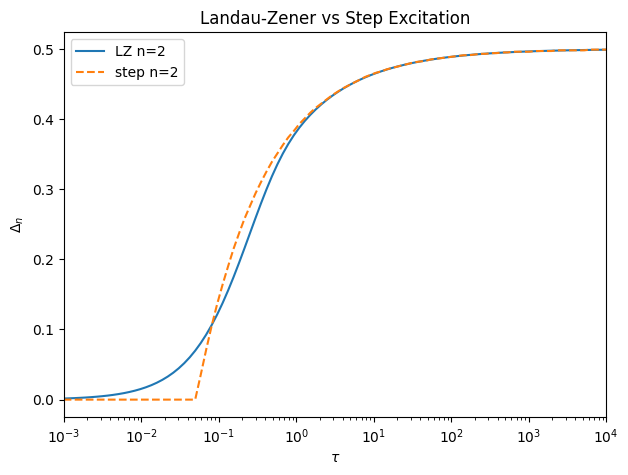

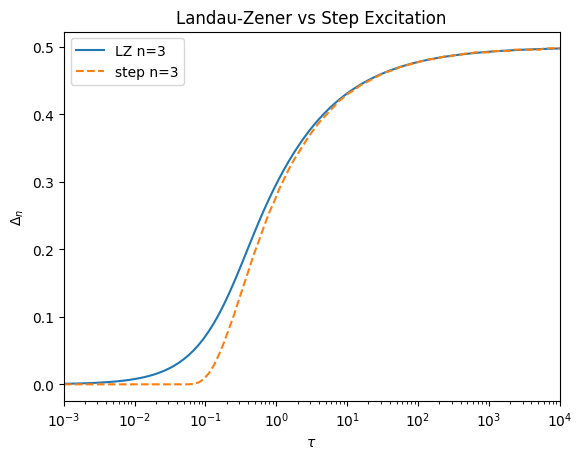

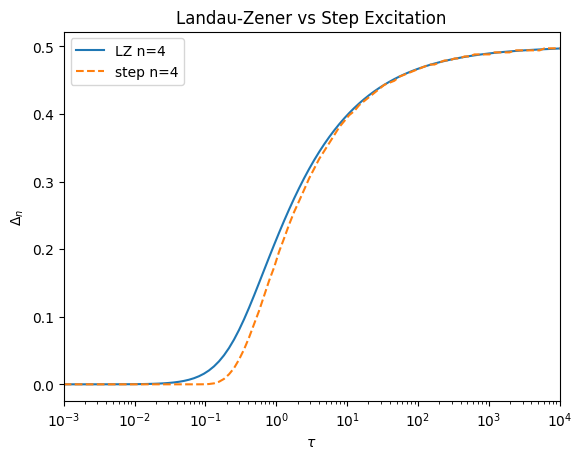

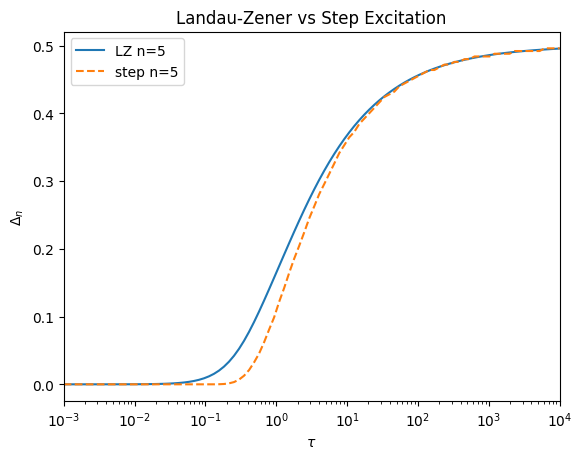

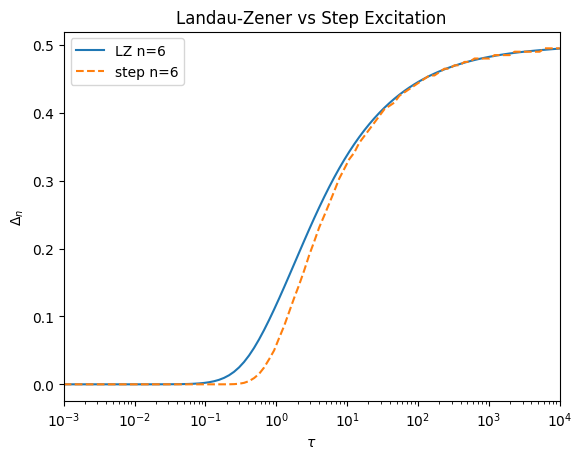

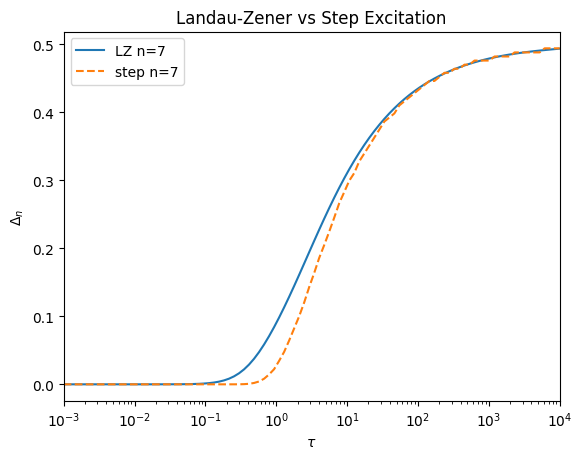

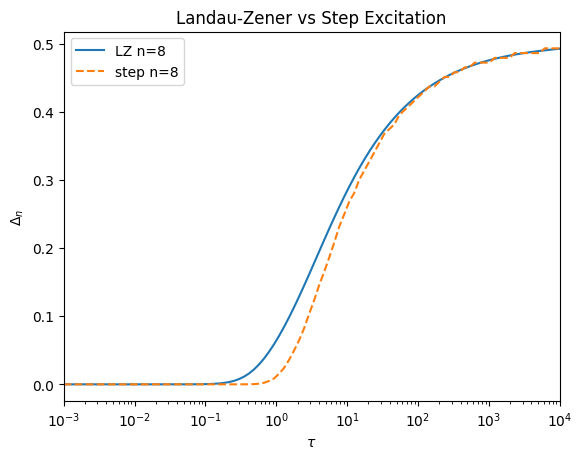

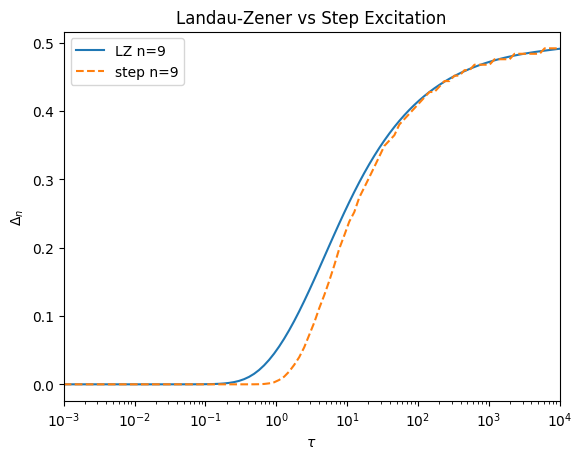

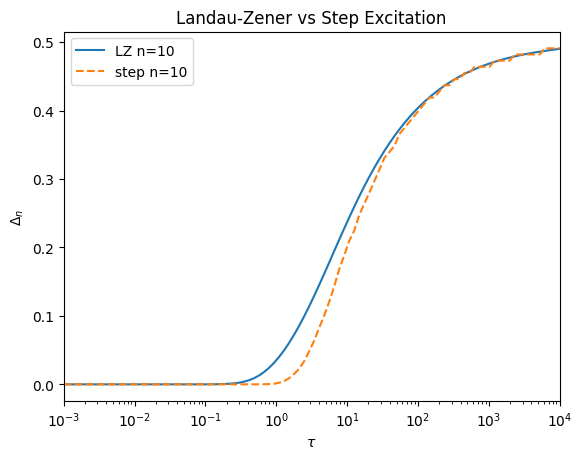

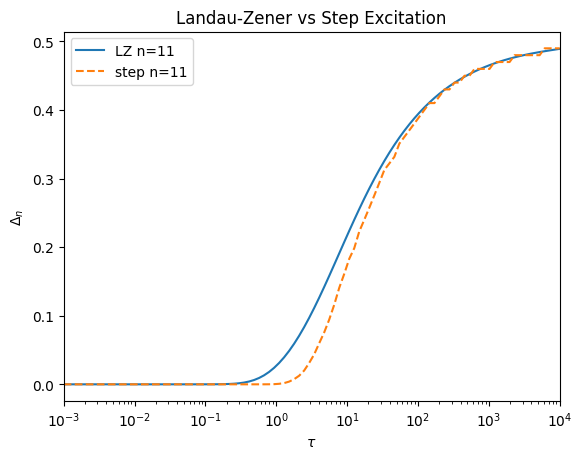

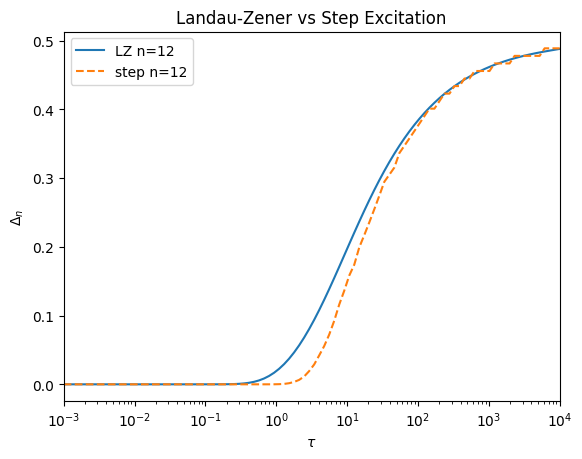

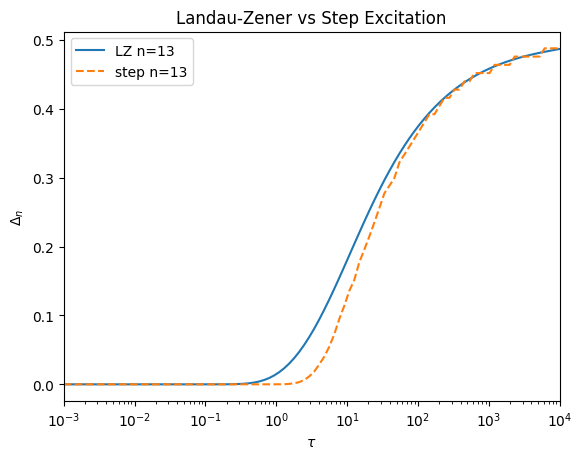

In [379]:
# -------- Δ_n comparison --------
plt.figure(figsize=(7,5))

for i,n in enumerate(ns):
    plt.plot(taus, out_lz[:,i], label=f"LZ n={n}")
    plt.plot(taus, out_step[:,i], "--", label=f"step n={n}")

    plt.xscale("log")
    plt.xlim(taus[0], taus[-1])
    plt.xlabel(r"$\tau$")
    plt.ylabel(r"$\Delta_n$")
    plt.legend()
    plt.title("Landau-Zener vs Step Excitation")
    plt.show()

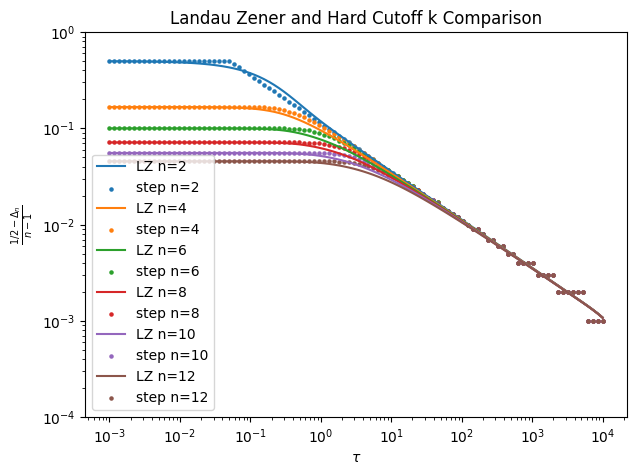

In [380]:
# -------- normalized comparison --------
plt.figure(figsize=(7,5))

for i,n in enumerate(ns[::2]):

    y_lz   = (1/2 - out_lz[:,2*i])/(n-1)
    y_step = (1/2 - out_step[:,2*i])/(n-1)

    plt.loglog(taus, y_lz, label=f"LZ n={n}")
    plt.scatter(taus, y_step, label=f"step n={n}",s=5)

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\frac{1/2-\Delta_n}{n-1}$")
plt.legend()
plt.title("Landau Zener and Hard Cutoff k Comparison")
plt.ylim(1e-4,1)
plt.show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


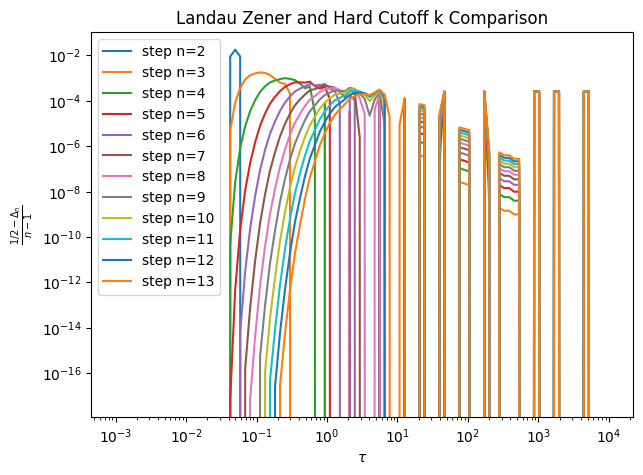

In [332]:
# -------- normalized comparison --------
plt.figure(figsize=(7,5))

for i,n in enumerate(ns):

    y_lz   = (1/2 - out_lz[:,i])/(n-1)
    y_step = (1/2 - out_step[:,i])/(n-1)

    #plt.loglog(taus, -np.gradient(np.gradient(y_lz)), label=f"LZ n={n}")
    plt.plot(taus,-np.gradient(np.gradient(y_step)), label=f"step n={n}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\frac{1/2-\Delta_n}{n-1}$")
plt.legend()
plt.title("Landau Zener and Hard Cutoff k Comparison")
#plt.ylim(1e-4,1)
loglog()
plt.show()

In [335]:
tau_peaks = []

mask = (taus >= 10e-3) & (taus <= 1e1)

for i,n in enumerate(ns):

    y_step = (1/2 - out_step[:,i])/(n-1)
    y_lz = (1/2- out_lz[:,i])/(n-1)
    g2 = -np.gradient(np.gradient(y_step, taus), taus)

    taus_window = taus[mask]
    g2_window = g2[mask]

    idx = np.argmax(g2_window)

    tau_peak = taus_window[idx]

    tau_peaks.append(tau_peak)

tau_peaks = np.array(tau_peaks)

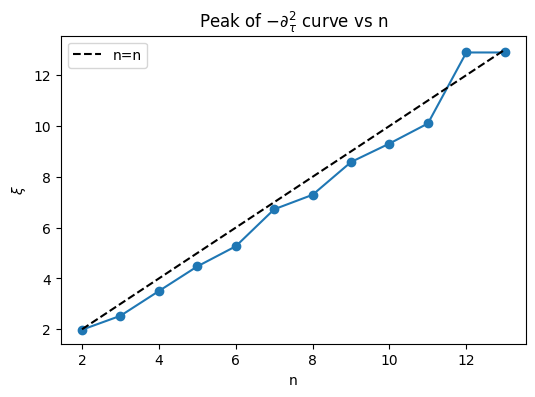

In [340]:
plt.figure(figsize=(6,4))
plt.plot(ns, 2*pi*sqrt(2*tau_peaks), "o-")

plt.xlabel("n")
plt.ylabel(r"$\xi$")
plt.title("Peak of $-\\partial_\\tau^2$ curve vs n")
plot(ns,ns,label="n=n",color="black",ls="--")

legend()
#loglog()
plt.show()

In [341]:
kz.state

NameError: name 'kz' is not defined

In [343]:
import analytical_quench_states as kz
taus = logspace(0,2,20)

states = [kz.state(100,tau,tau) for tau in taus]

In [363]:
x=array([op.sx_correlation([0,3],state) for state in states])
y=array([op.sx_correlation([0,1],state) for state in states])


[]

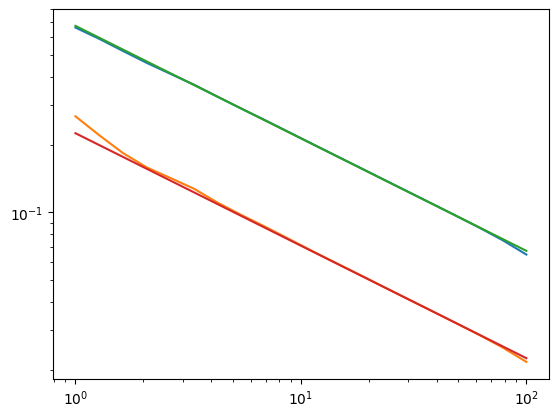

In [365]:
plot(taus,1-x)
plot(taus,1-y)
plot(taus,3/sqrt(2*taus)/pi)
plot(taus,1/sqrt(2*taus)/pi)

loglog()